In [ ]:
#| default_exp dg_clusters

In [ ]:
#| hide

import plotly.io as pio

In [ ]:
#| hide
#| eval: false
pio.renderers.default = "png"

In [ ]:
#| echo: false
#| eval: false
#| hide

from pathlib import Path
from execnb.nbio import read_nb
from nbdev.frontmatter import nb_frontmatter

# Clustering of Signals of Individual Faces

In [ ]:
#| hide
#| eval: false

import plotly.io as pio
import numpy as np
from scipy.spatial.distance import euclidean

In [ ]:
#| hide
#| eval: false

from fhemb import setup_logging
from fhemb.config.settings import THERMO_SR
from fhemb.utils.cutils import depict_clusters, dtw_clustering, prepare_data, split_scale_data, depict_DTW, plot_pr_heatmap, plot_clustered_pr_heatmap, plot_pr_dendrogram, plot_pr_projection, svd_pr
from fhemb.piece import Piece
from fhemb.utils.factories import wfactory, wfactories, pca_factory

DEBUG:fhemb.config.settings:Loading environment from /Users/radned/.config/fhemb/.env.paths
DEBUG:fhemb.config.settings:Loading environment from /Users/radned/.config/fhemb/.env.db
DEBUG:fhemb.config.settings:Running locally
/Users/radned/.pyenv/versions/p311.fhemb/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-05-06 13:45:56.705583: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/Users/radned/.pyenv/versions/p311.fhemb/lib/python3.11/site-packages/threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') 

In [ ]:
#| hide
#| eval: false

setup_logging(
    force=True,
    module_levels={
        "mixins": "WARNING",
        "piece": "INFO",
        "dbms": "INFO",
        "embedding": "INFO",
        "tutils": "INFO",
        "cutils": "INFO",
        "wdecomposition": "INFO",
        "wrepresentation": "INFO",
    },
)

In [ ]:
#| hide
#| eval: false

FFTRIO_DIRNAME = 'fftrio0_fftrio1/'
FFTRIO0011_DIRNAME = 'fftrio00_fftrio11/'
NGF0_FFTRIO1_DIRNAME = 'ngf0_fftrio1/'
NGF1_FFTRIO1_DIRNAME = 'ngf1_fftrio1/'
NGF_DIRNAME = 'ngf0_ngf1/'

In [ ]:
#| hide
#| eval: false

overture_interval = 6*60, 7*60
nottegiornofaticar_interval = 7*60 + 34.4, 7*60+54.4
murder_interval = 9*60+40, 10*60+40
ftrio_interval = 10*60+24.8, 11*60+38.8   # complete trio interval
fftrio_interval = 10*60+22.4, 11*60+42.4  # extended trio interval
death_interval = 10*60+40, 11*60+40

In [ ]:
#| hide
#| eval: false

overture_frames = tuple(map(lambda x: round((x-54.4)*THERMO_SR), overture_interval))
nottegiornofaticar_frames = tuple(map(lambda x: round((x-54.4)*THERMO_SR), nottegiornofaticar_interval))    
murder_frames = tuple(map(lambda x: round((x-54.4)*THERMO_SR), murder_interval))
ftrio_frames = tuple(map(lambda x: round((x-54.4)*THERMO_SR), ftrio_interval))
fftrio_frames = tuple(map(lambda x: round((x-54.4)*THERMO_SR), fftrio_interval))
death_frames= tuple(map(lambda x: round((x-54.4)*THERMO_SR), death_interval))

## Define Segments of the Opera

In [ ]:
#| eval: false

fftrio_segment00 = (14200, 14700)
fftrio_segment11 = (14950, 15450)

In [ ]:
#| hide
#| eval: false

nottegiornofaticar_segment0 = (10000, 10250)
nottegiornofaticar_segment1 = (10250, 10500)
fftrio_segment0 = (14200, 14450)
fftrio_segment1 = (14950, 15200)
fftrio_segment2 = (15950, 16200)
fftrio_segment00 = (14200, 14700)
fftrio_segment11 = (14950, 15450)
fftrio_segment22 = (15700, 16200)

In [ ]:
#| hide
#| eval: false

fftrio00 = Piece(
    time_interval=fftrio_segment00,  # time interval 
    title="Don Giovanni",            # opera
    subjs=(40,76)                    # interval of subjects of interest
)

In [ ]:
#| eval: false

fftrio0 = Piece(
    time_interval=fftrio_segment0,
    title="Don Giovanni", 
    subjs=(40,76)
)

In [ ]:
#| eval: false

fftrio1 = Piece(
    time_interval=fftrio_segment1,
    title="Don Giovanni", 
    subjs=(40,76)
)

In [ ]:
#| hide
#| eval: false

fftrio11 = Piece(
    time_interval=fftrio_segment11,
    title="Don Giovanni", 
    subjs=(40,76)
)

In [ ]:
#| hide
#| eval: false

fftrio2 = Piece(
    time_interval=fftrio_segment2, 
    title="Don Giovanni", subjs=(40,76))

In [ ]:
#| hide
#| eval: false

fftrio22 = Piece(
    time_interval=fftrio_segment22, 
    title="Don Giovanni", subjs=(40,76))

## Define Embeddings
> 85th percentile in the frequency band 0.05 - 0.1 Hz of the *Daubechies* wavelet `db4`

### Embed opera segments into a 1D feature space and concatenate the embeddings

1. Specify the embedding

In [ ]:
#| eval: false

fbands= [1]                      # frequency bands of interest       
features=['p85']                 # 1d-feature space - 85-percentile 
factory=wfactory('db4', level=8) # Wavelet transform: daubechies 4, level 8

2. Retrieve data from the Database and calculate the specified embedding

In [ ]:
#| eval: false

emb0 = fftrio0.face_t.project(  
    fbands=fbands,
    features=features,
    wdfactory=factory
)

emb1 = fftrio1.face_t.project(  
    fbands=fbands,
    features=features,
    wdfactory=factory
)

 [INFO] piece._load_from_db: Loading face_t from the database
 [INFO] piece._fetch_from_DB: Fetching data by query SELECT subj40, subj41, subj42, subj43, subj44, subj45, subj46, subj47, subj48, subj49, subj50, subj51, subj52, subj53, subj54, subj55, subj56, subj57, subj58, subj59, subj60, subj61, subj62, subj63, subj64, subj65, subj66, subj67, subj68, subj69, subj70, subj71, subj72, subj73, subj74, subj75, subj76 FROM dg.faceposition_t WHERE frame_number >= 14200 AND frame_number < 14450 ORDER BY frame_number
 [INFO] dbms.data_query: Fetching time series of ['subj40', 'subj41', 'subj42', 'subj43', 'subj44', 'subj45', 'subj46', 'subj47', 'subj48', 'subj49', 'subj50', 'subj51', 'subj52', 'subj53', 'subj54', 'subj55', 'subj56', 'subj57', 'subj58', 'subj59', 'subj60', 'subj61', 'subj62', 'subj63', 'subj64', 'subj65', 'subj66', 'subj67', 'subj68', 'subj69', 'subj70', 'subj71', 'subj72', 'subj73', 'subj74', 'subj75', 'subj76']
 [INFO] piece.fetch_timeseries: 250 rows fetched successfully!
 [

In [ ]:
emb0.frequencies

[(0.05, 0.1)]

3. Organize the embeddings into a single matrix (subjects x time steps)

In [ ]:
#| eval: false

Xopera0 = np.stack([
    emb0.features_tint[subj] for subj in emb00.subjects
])

Xopera1 = np.stack([
    emb1.features_tint[subj] for subj in emb11.subjects
])

Xopera = np.concatenate([Xopera0, Xopera1])

## Heatmap Depicts DWT Pairwise Distances

### Non-clustered

 [INFO] cutils.calc_pairwise_relation: Using euclidean alignment metric
Computing distances: 100%|██████████| 2080/2080 [00:28<00:00, 74.12it/s]


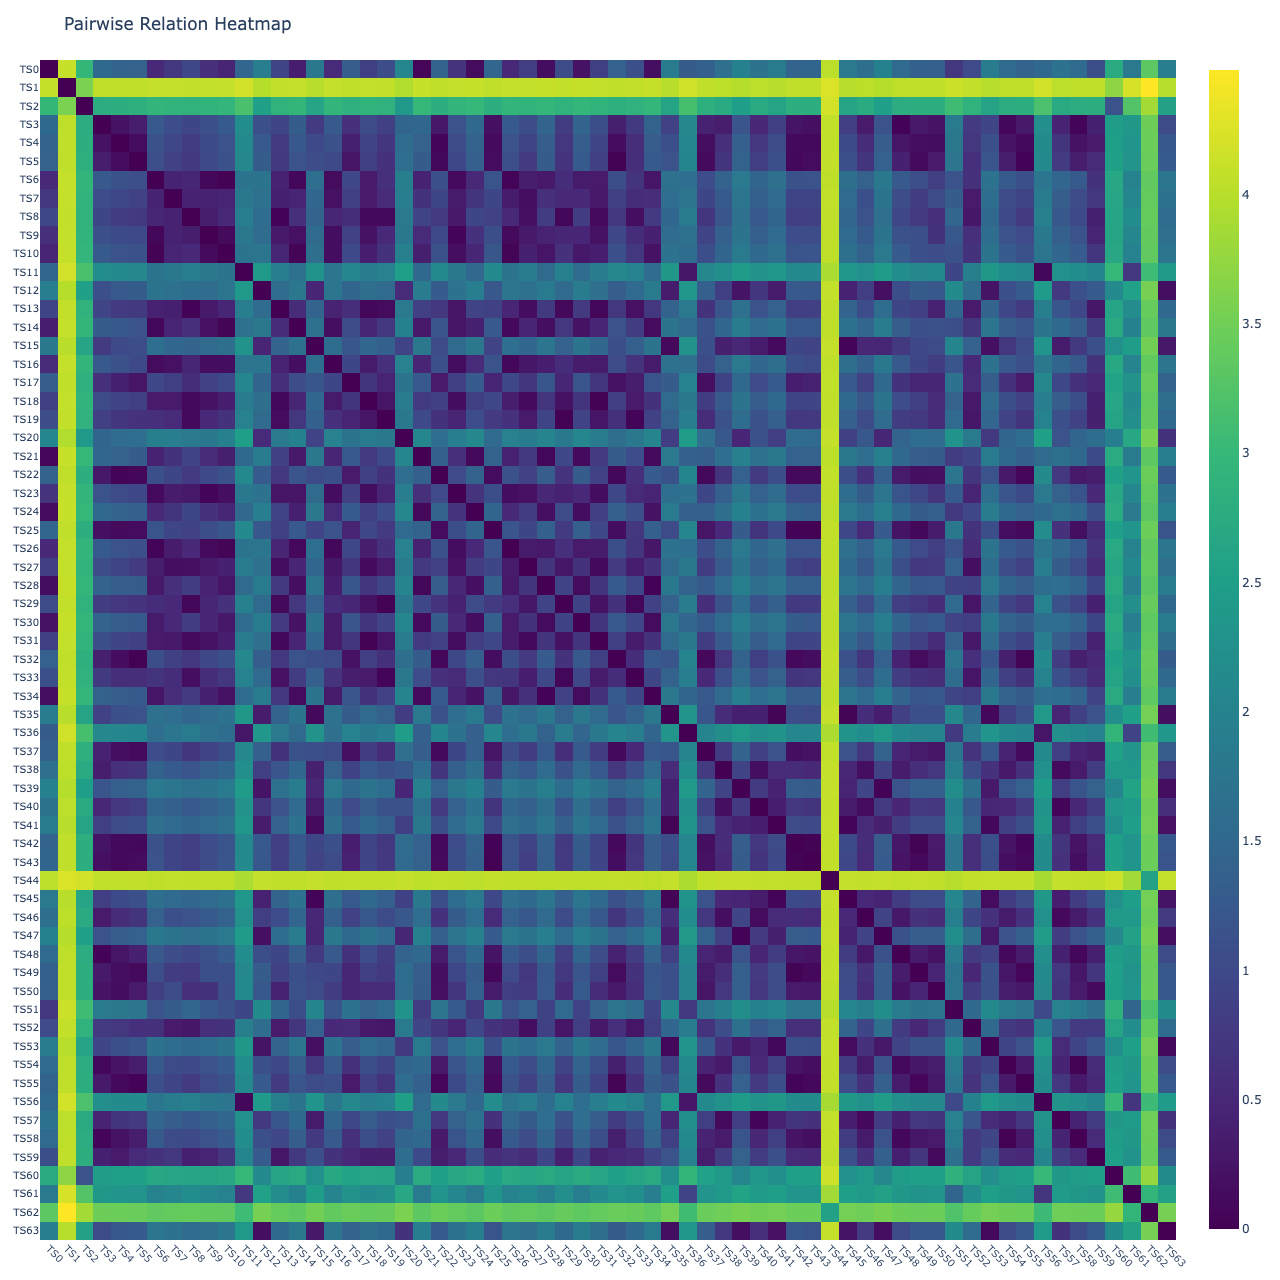

In [ ]:
#| echo: true
#| eval: false

plot_pr_heatmap(
    Xopera,                    # embedded opera segments 
    alignment_type='fastdtw',  # alignment type for distance matrix computation
    gamma=1,                   # soft-DTW gamma parameter (if applicable)
    dist=euclidean,            # distance metric for distance matrix computation (if applicable)
    normalize='log',           # normalization method for distance matrix ('log', 'zscore', or None)
    n_jobs=8                   # number of parallel jobs for accelerating the distance matrix computation
)

### Clustered

 [INFO] cutils.calc_pairwise_relation: Using euclidean alignment metric
Computing distances: 100%|██████████| 2080/2080 [00:25<00:00, 81.35it/s]


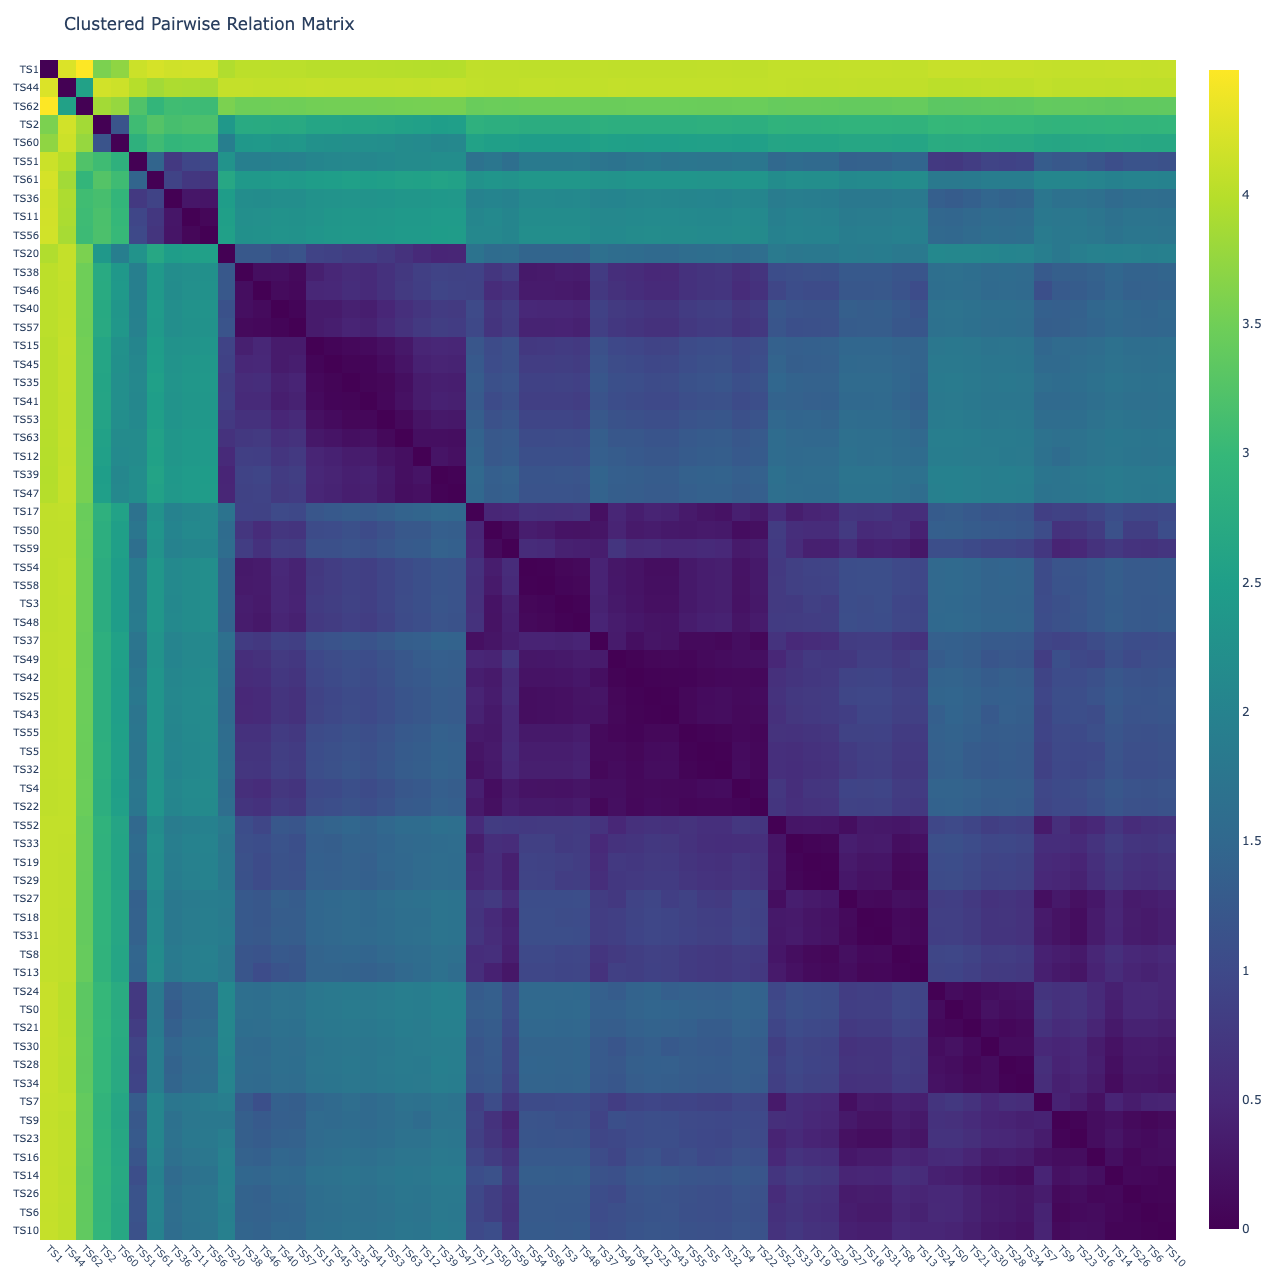

In [ ]:
#| eval: false

plot_clustered_pr_heatmap(
    Xopera, 
    alignment_type='fastdtw', 
    gamma=1, 
    normalize='log', 
    n_jobs=8
) 

## Geometry ot the Pairwise Embedding

### Projection of the pairwise embedding into a low-dimensional space

 [INFO] cutils.calc_pairwise_relation: Using euclidean alignment metric
Computing distances: 100%|██████████| 2080/2080 [00:26<00:00, 78.57it/s]


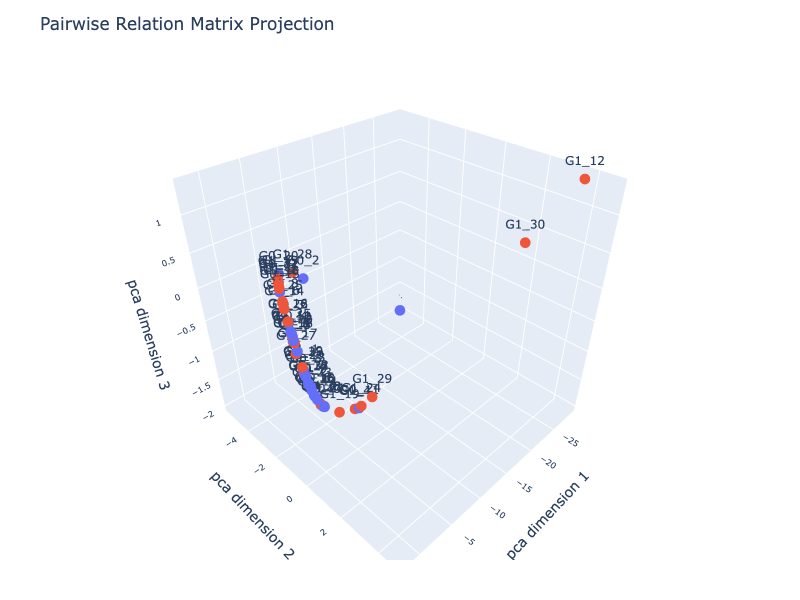

In [ ]:
#| eval: false

plot_pr_projection(
    Xopera0, 
    Xopera1, 
    alignment_type='fastdtw', 
    gamma=1, 
    projection='pca', 
    transformation='minmax', 
    normalize='z-score', 
    n_jobs=8, 
    dimensions=3
) 

### Singular value decomposition of the pairwise embedding

In [ ]:
#| eval: false

U, S, Vt = svd_pr(
    Xopera, 
    alignment_type='fastdtw', 
    gamma=1, 
    transformation='minmax', 
    normalize='z-score', 
    n_jobs=8
)

 [INFO] cutils.calc_pairwise_relation: Using euclidean alignment metric
Computing distances: 100%|██████████| 2080/2080 [00:32<00:00, 64.55it/s]


In [ ]:
#| eval: false

import matplotlib.pyplot as plt

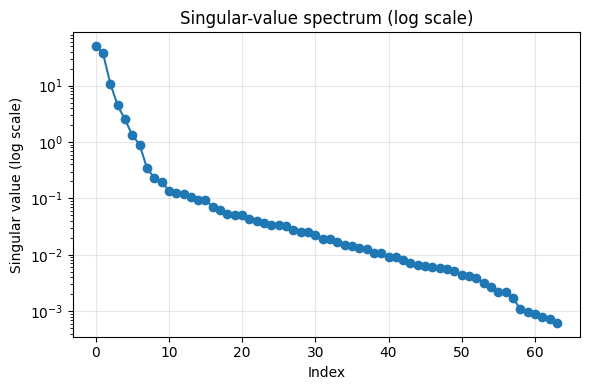

In [ ]:
#| eval: false

plt.figure(figsize=(6, 4))
plt.semilogy(S, marker='o', linewidth=1.5)
plt.xlabel("Index")
plt.ylabel("Singular value (log scale)")
plt.title("Singular-value spectrum (log scale)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
#| hide
#| eval: false
COLUMNS_FILTER=[
        'knn_precomputed', 
        'knn_cosine', 
        'knn_l1', 
        'knn_euclidean', 
        'knn_minkowski', 
        'rotf', 
        'randf', 
        'svm_precomputed', 
        'svm_rbf', 
        'svm_poly', 
        'svm_linear'
    ]

## Clusters of Embeddings

In [ ]:
#| eval: false
#| hide

from collections import defaultdict

In [ ]:
#| eval: false

from fhemb.utils.cutils import compute_silhouette_vs_k, plot_silhouette_curves


### Number of clusters in the first segment

In [ ]:
#| eval: false

results0 = defaultdict(dict)

for i in [0, 50, 100, 150]:       
    result =compute_silhouette_vs_k(
        emb0,                         # the embedding object (EmbeddingCollection) that contains the time series to cluster 
        interval=(i,i+100),           # the interval of frames to cluster
        normalize=False,              # to normalize the time series before clustering (`minmax` or `meanvar`)
        metric='dtw',                 # Distance metric for clustering in K-means algorithm.
        max_k=10,                     # maximum number of clusters to evaluate 
        max_iter=10,                  # maximum number of iterations for K-means algorithm
        random_state=0,               # random state for K-means algorithm
        n_jobs=8                      # number of parallel jobs
    )
    results0[i]=result                 # store results in dictionary for later plotting

Silhouette k-scan:   0%|          | 0/9 [00:00<?, ?it/s] [DEBUG] embedding.__getattr__: Accessing attribute/method 'features_tint' across embeddings: found in ['percentiles_ts']
 [DEBUG] embedding.__getattr__: Accessing attribute/method 'features_tint' across embeddings: found in ['percentiles_ts']
 [DEBUG] embedding.__getattr__: Accessing attribute/method 'subjects' across embeddings: found in ['percentiles_ts']
 [DEBUG] embedding.__getattr__: Accessing attribute/method 'features_tint' across embeddings: found in ['percentiles_ts']
 [DEBUG] embedding.__getattr__: Accessing attribute/method 'features_tint' across embeddings: found in ['percentiles_ts']
 [DEBUG] embedding.__getattr__: Accessing attribute/method 'features_tint' across embeddings: found in ['percentiles_ts']
 [DEBUG] embedding.__getattr__: Accessing attribute/method 'features_tint' across embeddings: found in ['percentiles_ts']
 [DEBUG] embedding.__getattr__: Accessing attribute/method 'features_tint' across embeddings: f

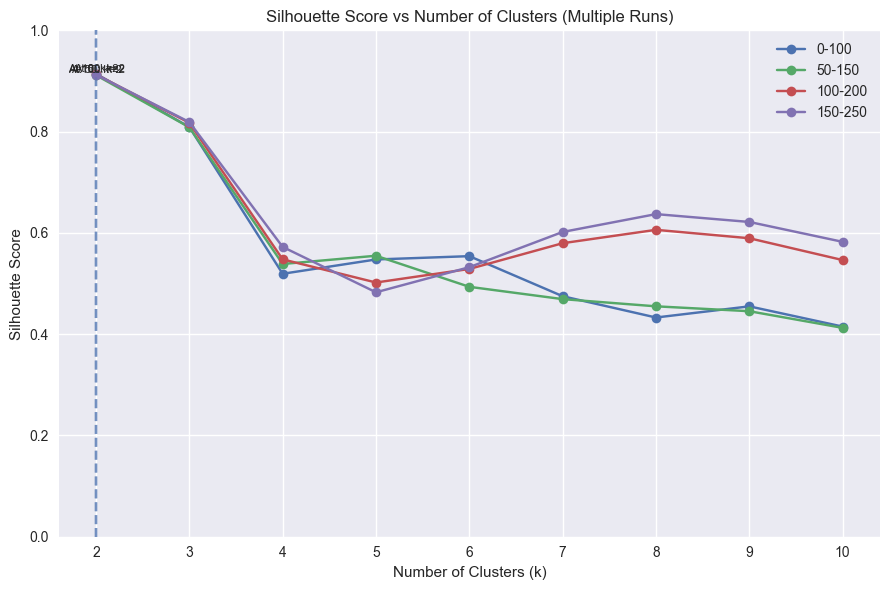

In [ ]:
#| eval: false

plot_silhouette_curves(
    results0,                                            # dictionary of silhouette results for different intervals
    labels=['0-100', '50-150', '100-200', '150-250'],    # labels for each interval
    show_best = True,                                    # whether to highlight the best silhouette score across intervals
    filepath='emb0'                                      # filepath for saving the plot  
)

### Number of clusters in the second segment

In [ ]:
#| eval: false

cluster0_t = defaultdict(dict)

keys = [  
    "clusters_subj",
    "subj_clusters",
    "labels",
    "silhouette",
    "centroids",
]

for i in [0, 50, 100, 150]:
    _values = dtw_clustering(
        emb0,                        # the embedding object (EmbeddingCollection) that contains the time series to cluster
        interval=(i,i+100),          # the interval of frames to cluster
        normalize=False,             # whether to normalize the time series before clustering
        metric = "dtw",              # the distance metric for clustering
        n_clusters=4,                # the number of clusters to form
        max_iter=15,                 # the maximum number of iterations for the K-means algorithm
        random_state=0               # the random state for reproducibility
    )

    cluster0_t[i] = dict(zip(keys, _values))  # store results in dictionary for later analysis and plotting

/Users/radned/.pyenv/versions/p311.fhemb/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/radned/.pyenv/versions/p311.fhemb/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/radned/.pyenv/versions/p311.fhemb/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/radned/.pyenv/versions/p311.fhemb/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/radned/.pyenv/versions/p311.fhemb/lib/python3.11/site-packages/sklearn/utils/deprecation.py:1

In [ ]:
#| eval: false

results1 = defaultdict(dict)

for i in [0, 50, 100, 150]:       
    result =compute_silhouette_vs_k(
        emb1,                         # the embedding object (EmbeddingCollection) that contains the time series to cluster 
        interval=(i,i+100),           # the interval of frames to cluster
        normalize=False,              # to normalize the time series before clustering (`minmax` or `meanvar`)
        metric='dtw',                 # Distance metric for clustering in K-means algorithm.
        max_k=10,                     # maximum number of clusters to evaluate 
        max_iter=10,                  # maximum number of iterations for K-means algorithm
        random_state=0,               # random state for K-means algorithm
        n_jobs=8                      # number of parallel jobs
    )
    results1[i]=result                 # store results in dictionary for later plotting

Silhouette k-scan:   0%|          | 0/9 [00:00<?, ?it/s] [DEBUG] embedding.__getattr__: Accessing attribute/method 'features_tint' across embeddings: found in ['percentiles_ts']
 [DEBUG] embedding.__getattr__: Accessing attribute/method 'features_tint' across embeddings: found in ['percentiles_ts']
 [DEBUG] embedding.__getattr__: Accessing attribute/method 'subjects' across embeddings: found in ['percentiles_ts']
 [DEBUG] embedding.__getattr__: Accessing attribute/method 'features_tint' across embeddings: found in ['percentiles_ts']
 [DEBUG] embedding.__getattr__: Accessing attribute/method 'features_tint' across embeddings: found in ['percentiles_ts']
 [DEBUG] embedding.__getattr__: Accessing attribute/method 'features_tint' across embeddings: found in ['percentiles_ts']
 [DEBUG] embedding.__getattr__: Accessing attribute/method 'features_tint' across embeddings: found in ['percentiles_ts']
 [DEBUG] embedding.__getattr__: Accessing attribute/method 'features_tint' across embeddings: f

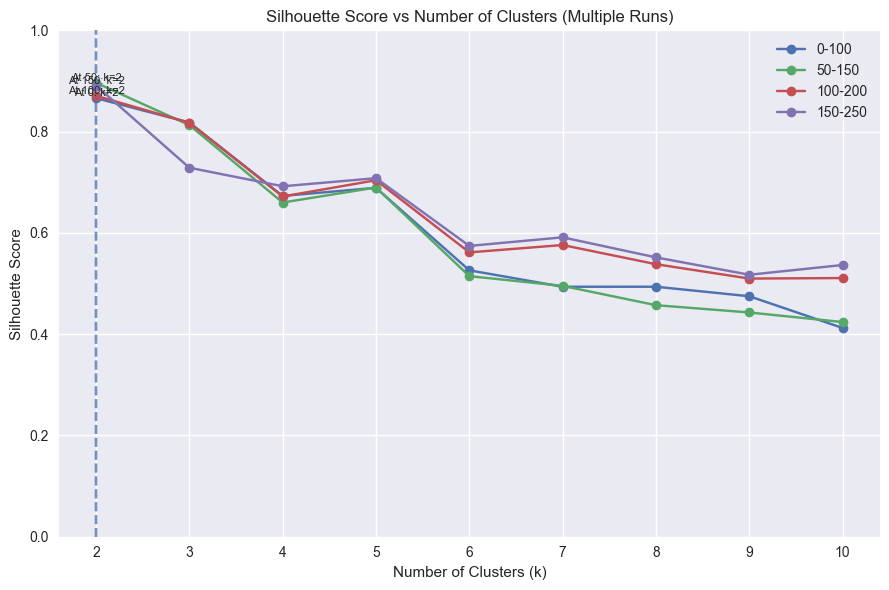

In [ ]:
#| eval: false

plot_silhouette_curves(
    results1,                                             # dictionary of silhouette results for different intervals
    labels=['0-100', '50-150', '100-200', '150-250'],    # labels for each interval
    show_best = True,                                    # whether to highlight the best silhouette score across intervals
    filepath='emb1'                       # filepath for saving the plot  
)

In [ ]:
#| eval: false

cluster1_t = defaultdict(dict)

keys = [  
    "clusters_subj",
    "subj_clusters",
    "labels",
    "silhouette",
    "centroids",
]

for i in [0, 50, 100, 150]:
    _values = dtw_clustering(
        emb1,                        # the embedding object (EmbeddingCollection) that contains the time series to cluster
        interval=(i,i+100),          # the interval of frames to cluster
        normalize=False,             # whether to normalize the time series before clustering
        metric = "dtw",              # the distance metric for clustering
        n_clusters=4,                # the number of clusters to form
        max_iter=15,                 # the maximum number of iterations for the K-means algorithm
        random_state=0               # the random state for reproducibility
    )

    cluster1_t[i] = dict(zip(keys, _values))  # store results in dictionary for later analysis and plotting

/Users/radned/.pyenv/versions/p311.fhemb/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/radned/.pyenv/versions/p311.fhemb/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/radned/.pyenv/versions/p311.fhemb/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/radned/.pyenv/versions/p311.fhemb/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/radned/.pyenv/versions/p311.fhemb/lib/python3.11/site-packages/sklearn/utils/deprecation.py:1

### Cluster visualization

In [ ]:
#| eval: false
from nbdev_fhemb.piece_ex import dg0    # The `Piece` object that contains the original time series data and metadata for the first subject in the dataset. 
                                        # This is used for visualizing the clustered time series in the next step.

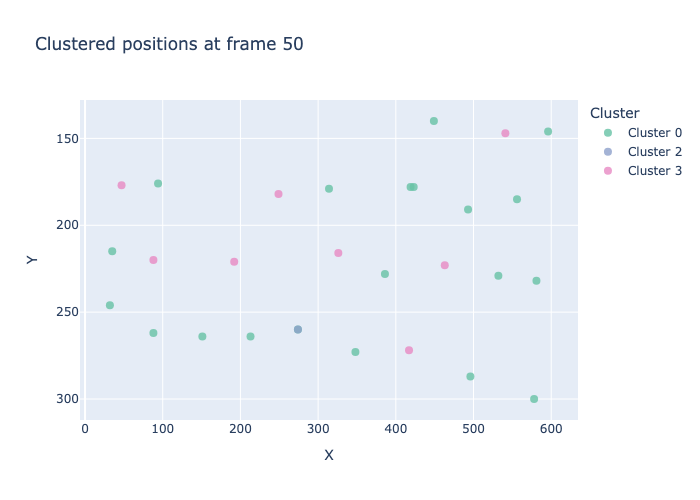

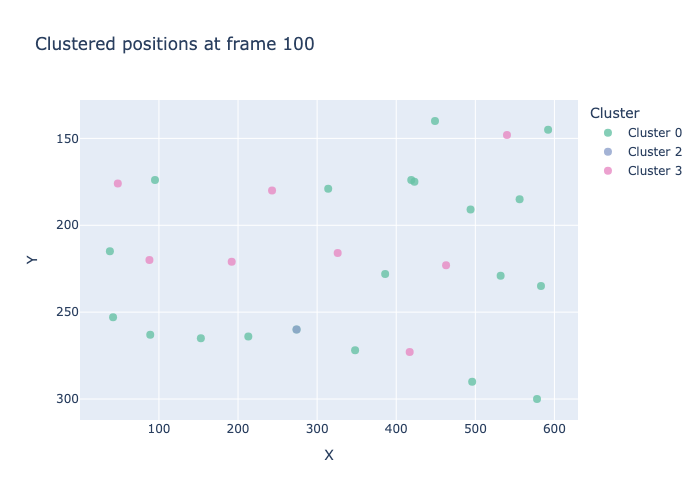

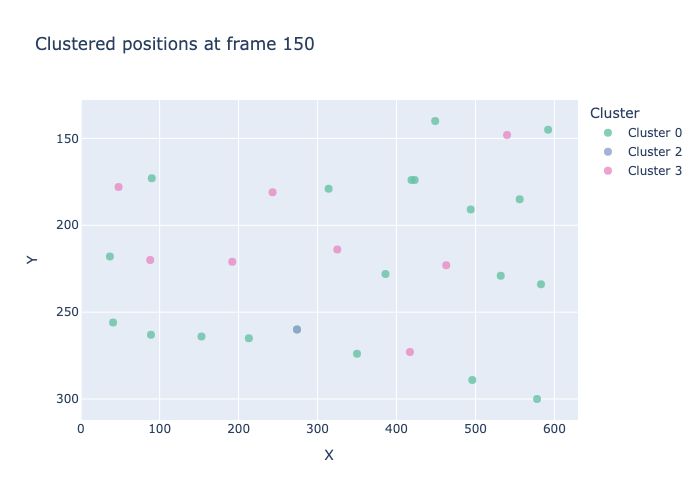

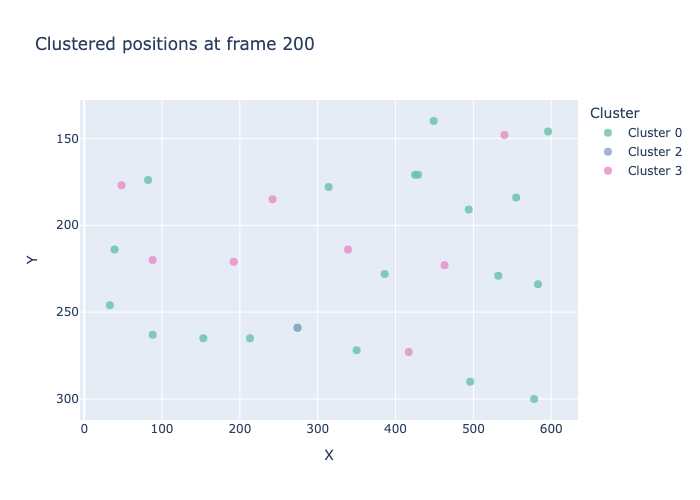

In [ ]:
#| eval: false

for frame, clusters in cluster0_t.items():     # iterate over each interval and its corresponding clustering results
    depict_clusters(
        clusters['clusters_subj'],             # the cluster assignments for each time series in the interval
        dg0.face_t.position.features_tint,     # the coordinates of the subject positions corresponding to the time series
        frame=frame+50                         # the frame number to visualize (the interval center)
    )

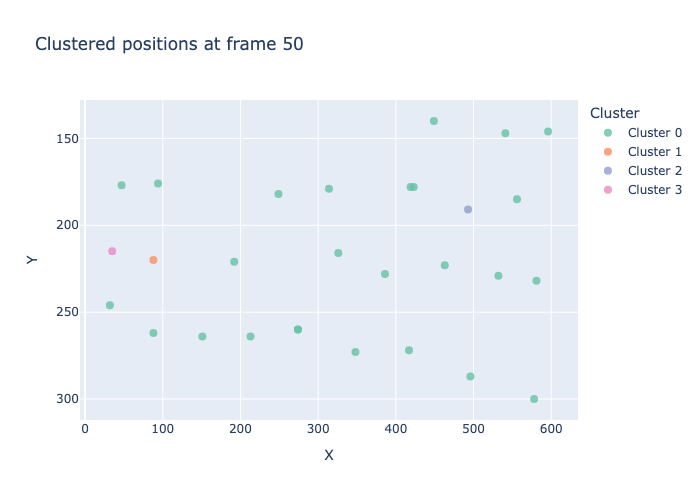

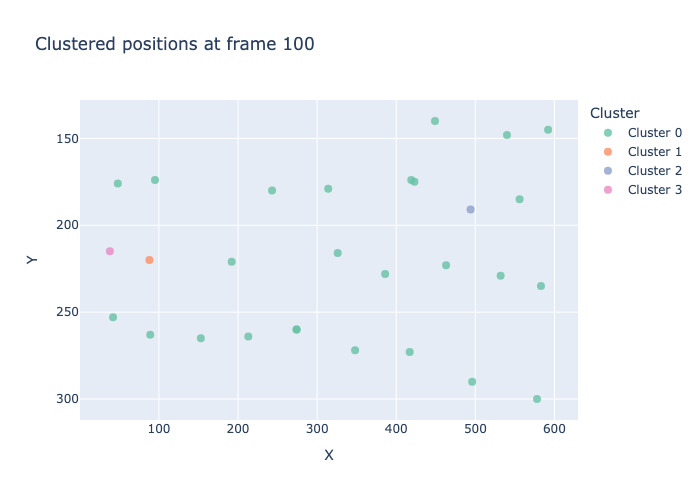

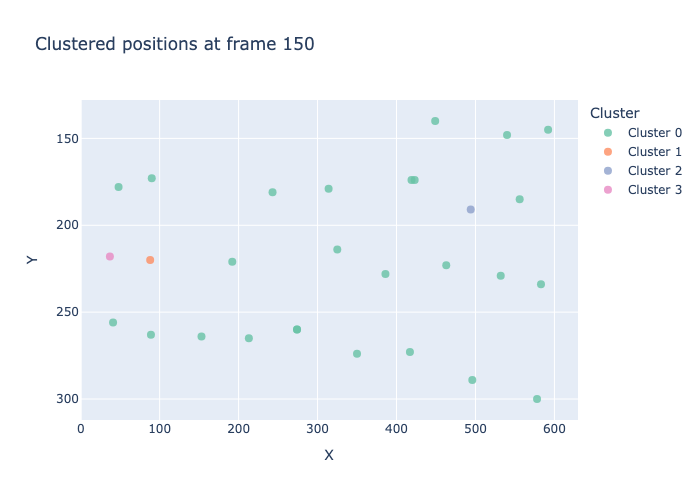

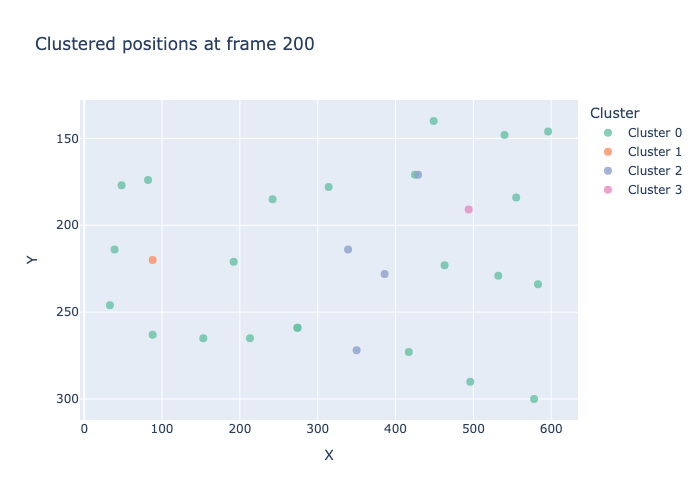

In [ ]:
#| eval: false

for frame, clusters in cluster1_t.items():     # iterate over each interval and its corresponding clustering results
    depict_clusters(
        clusters['clusters_subj'],             # the cluster assignments for each time series in the interval
        dg0.face_t.position.features_tint,     # the coordinates of the subject positions corresponding to the time series
        frame=frame+50                        # the frame number to visualize (the interval center)
    )